# Projet Data : Exploration de la ponctualité des TGV

Ce notebook constitue la première étape de notre projet. Nous allons explorer les données brutes, les nettoyer et préparer les variables nécessaires à la prédiction.

**Objectifs :**
1. Analyse exploratoire avec `skrub`.
2. Nettoyage des données (valeurs manquantes, types).
3. Création de la variable cible (taux de retard).
4. Visualisations de base.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

try:
    from skrub import TableReport
except ImportError:
    !pip install skrub
    from skrub import TableReport

sns.set_theme(style='whitegrid')
%matplotlib inline

# --- CONFIGURATION DES CHEMINS ---
# On définit le dossier racine du projet à partir du chemin fourni
base_path = Path(r'C:/Users/Utilisateur/Documents/Albert School/B2/SEMESTRE 2/Achieving a ML Proof of Concept/ml-poc-project')
data_dir = base_path / 'data'
raw_data_path = data_dir  / 'data_brutes.csv'
processed_dir = data_dir

print(f"Dossier de base : {base_path}")
print(f"Dossier cible pour sauvegarde : {processed_dir}")

Dossier de base : C:\Users\Utilisateur\Documents\Albert School\B2\SEMESTRE 2\Achieving a ML Proof of Concept\ml-poc-project
Dossier cible pour sauvegarde : C:\Users\Utilisateur\Documents\Albert School\B2\SEMESTRE 2\Achieving a ML Proof of Concept\ml-poc-project\data


## 1. Chargement des données brutes
On charge le fichier CSV 

In [2]:
if not raw_data_path.exists():
    print(f"⚠️ ERREUR : Le fichier est introuvable à l'adresse : {raw_data_path}")
else:
    df = pd.read_csv(raw_data_path, sep=';')
    print(f"Données chargées : {df.shape[0]} lignes.")
    display(df.head())

Données chargées : 8874 lignes.


,Date,Service,Gare de départ,Gare d'arrivée,Durée moyenne du trajet,Nombre de circulations prévues,Nombre de trains annulés,Commentaire annulations,Nombre de trains en retard au départ,Retard moyen des trains en retard au départ,...,Nombre trains en retard > 15min,Retard moyen trains en retard > 15 (si liaison concurrencée par vol),Nombre trains en retard > 30min,Nombre trains en retard > 60min,Prct retard pour causes externes,Prct retard pour cause infrastructure,Prct retard pour cause gestion trafic,Prct retard pour cause matériel roulant,Prct retard pour cause gestion en gare et réutilisation de matériel,"Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)"
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141,870,5,NaN,289,11.247809,...,110,6.511118,44,8,36.134454,31.092437,10.924370,15.966387,5.042017,0.840336
1,2018-01,National,LA ROCHELLE VILLE,PARIS MONTPARNASSE,165,222,0,NaN,8,2.875000,...,22,5.696096,5,0,15.384615,30.769231,38.461538,11.538462,3.846154,0.000000
2,2018-01,National,PARIS MONTPARNASSE,QUIMPER,220,248,1,NaN,37,9.501351,...,26,7.548387,17,7,26.923077,38.461538,15.384615,19.230769,0.000000,0.000000
3,2018-01,National,PARIS MONTPARNASSE,ST MALO,156,102,0,NaN,12,19.912500,...,8,6.724757,6,4,23.076923,46.153846,7.692308,15.384615,7.692308,0.000000
4,2018-01,National,PARIS MONTPARNASSE,ST PIERRE DES CORPS,61,391,2,NaN,61,7.796995,...,17,3.346487,6,0,21.212121,42.424242,9.090909,21.212121,6.060606,0.000000


## 2. Exploration automatique avec Skrub
Cet outil génère un rapport interactif pour visualiser les distributions et les données manquantes.

In [3]:
report = TableReport(df)
report

Processing column  26 / 26


,,,,,,,,,,,,,,,,,,,,,,,,,,


## 3. Nettoyage et Préparation
- Suppression des colonnes vides.
- Conversion des dates.

In [4]:
# Nettoyage
df_clean = df.drop(columns=['Commentaire annulations', 'Commentaire retards au départ'], errors='ignore').copy()
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

# Variable Cible
df_clean['trains_reels'] = df_clean['Nombre de circulations prévues'] - df_clean['Nombre de trains annulés']
df_clean['taux_retard'] = df_clean["Nombre de trains en retard à l'arrivée"] / df_clean['trains_reels']
df_clean['taux_retard'] = df_clean['taux_retard'].replace([np.inf, -np.inf], 0).fillna(0)

print('Nettoyage terminé.')

Nettoyage terminé.


## 4. Calcul du taux de retard (Cible)
Formule : $\text{Taux} = \frac{\text{Trains en retard}}{\text{Trains prévus} - \text{Trains annulés}}$

In [5]:
df['trains_circulant'] = df['Nombre de circulations prévues'] - df['Nombre de trains annulés']
df['taux_retard'] = df["Nombre de trains en retard à l'arrivée"] / df['trains_circulant']

# On gère les divisions par zéro
df['taux_retard'] = df['taux_retard'].replace([np.inf, -np.inf], 0).fillna(0)

df['taux_retard'].describe()

count    8874.000000
mean        0.143473
std         0.086072
min         0.000000
25%         0.088235
50%         0.127907
75%         0.181021
max         1.000000
Name: taux_retard, dtype: float64

## 5. Visualisations

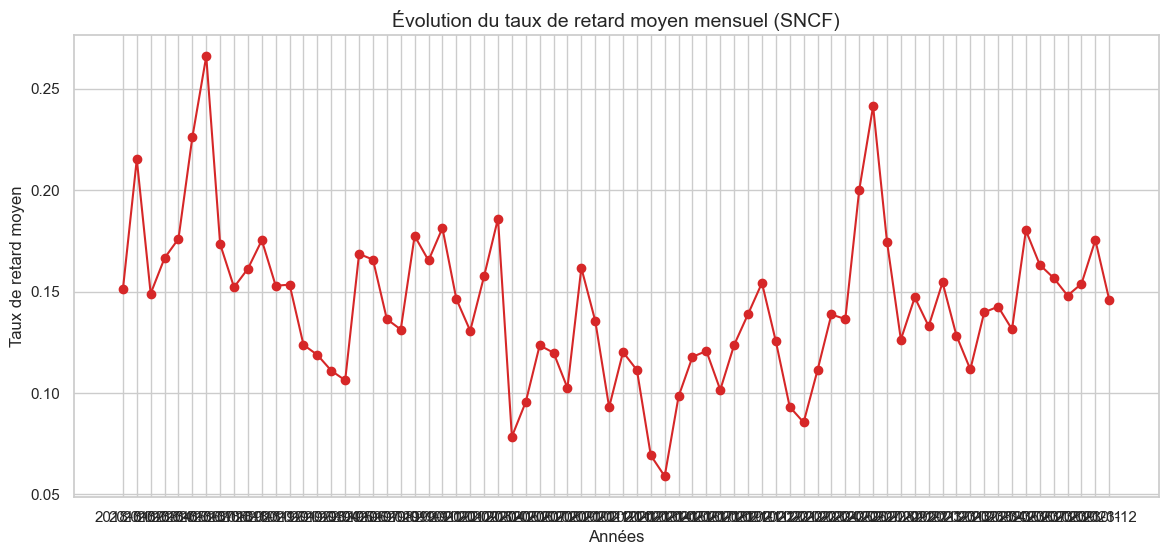

In [6]:
plt.figure(figsize=(14, 6))
df_evol = df.groupby('Date')['taux_retard'].mean()
plt.plot(df_evol.index, df_evol.values, color='tab:red', marker='o', linestyle='-')
plt.title('Évolution du taux de retard moyen mensuel (SNCF)', fontsize=14)
plt.ylabel('Taux de retard moyen')
plt.xlabel('Années')
plt.show()

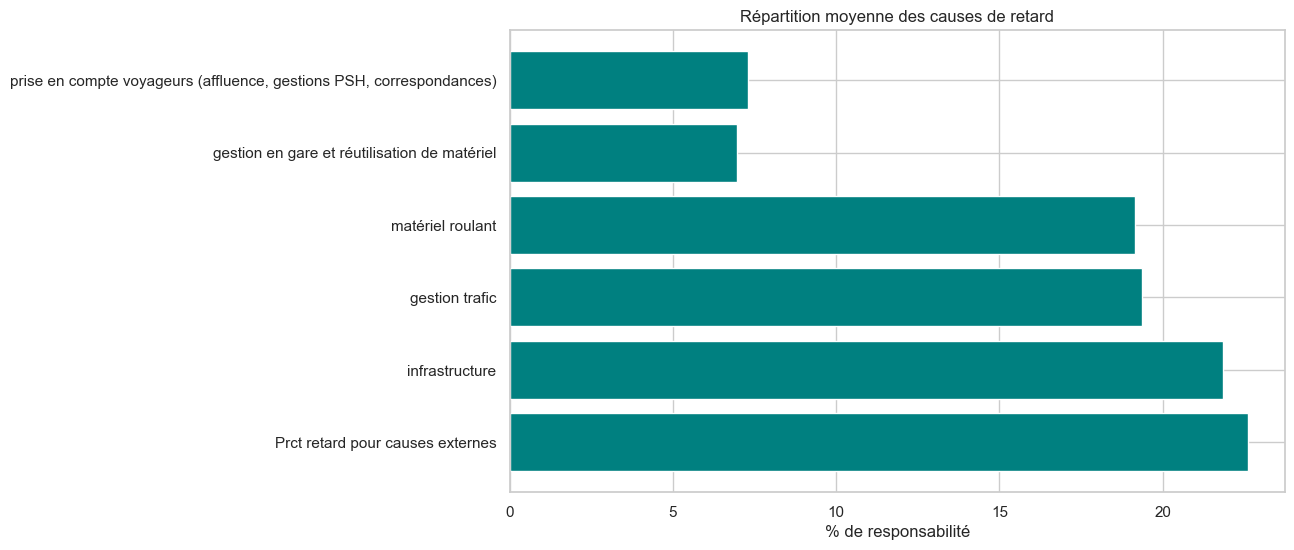

In [7]:
# Analyse des causes
causes_cols = [c for c in df.columns if 'Prct retard' in c]
# Nettoyage des noms pour le graphe
causes_names = [c.replace('Prct retard pour cause ', '') for c in causes_cols]

plt.figure(figsize=(10, 6))
plt.barh(causes_names, df[causes_cols].mean().values, color='teal')
plt.title('Répartition moyenne des causes de retard')
plt.xlabel('% de responsabilité')
plt.show()

## 6. Sauvegarde des données nettoyées
Cette étape crée un fichier `data_nettoyee.csv` qui nous servira pour la partie Machine Learning.

In [8]:
# Création du dossier s'il n'existe pas
processed_dir.mkdir(parents=True, exist_ok=True)

# Sauvegarde
output_file = processed_dir / 'data_nettoyee.csv'
df_clean.to_csv(output_file, index=False)

print(f"✅ Succès ! Le fichier a été sauvegardé dans :\n{output_file}")

✅ Succès ! Le fichier a été sauvegardé dans :
C:\Users\Utilisateur\Documents\Albert School\B2\SEMESTRE 2\Achieving a ML Proof of Concept\ml-poc-project\data\data_nettoyee.csv
